In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [48]:
#Load Dataset
df = pd.read_csv(r"C:\Users\DAKSH\Downloads\customer-churn-prediction-advanced\dataset\churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [49]:
#Dataset Overview
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


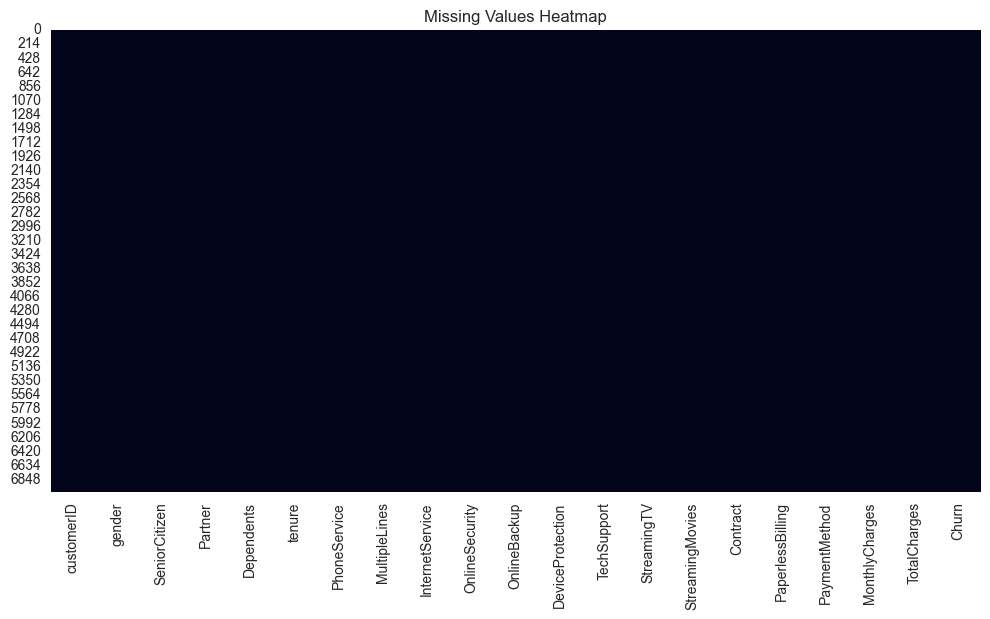

In [50]:
#Missing Values checking
df.isnull().sum()
#Visualization
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [51]:
#Duplicate Rows
df.duplicated().sum()
# if any duplicate 
# df.drop_duplicates(inplace=True)

np.int64(0)

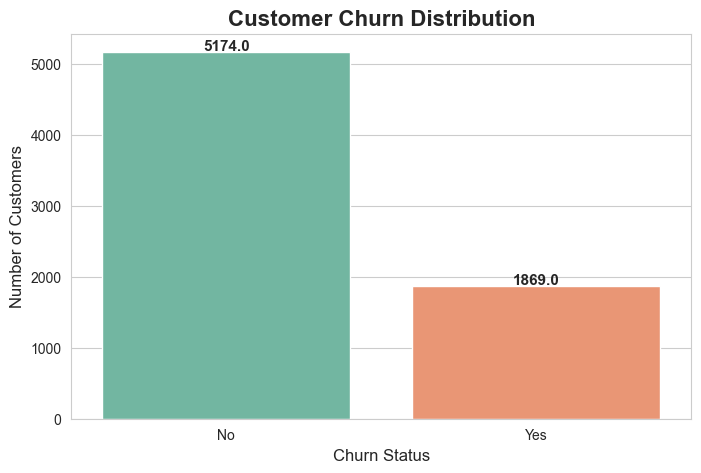

In [52]:
#Target Variable Analysis
df['Churn'].value_counts()
#Visualization
plt.figure(figsize=(8,5))
ax = sns.countplot(
    x='Churn',
    data=df,
    palette='Set2'
)

# Title
plt.title("Customer Churn Distribution", fontsize=16, fontweight='bold')

# Axis labels
plt.xlabel("Churn Status", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Add count labels
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height + 20,
        f'{height}',
        ha="center",
        fontsize=11,
        fontweight="bold"
    )
plt.show()

Numerical Features:
 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


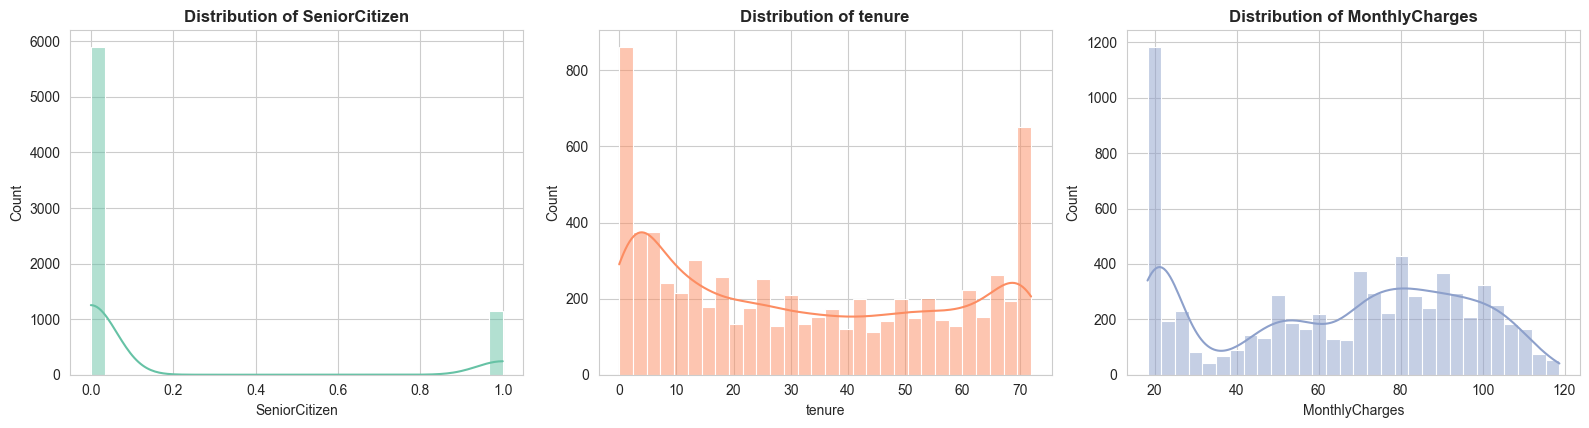

In [61]:
#Numerical Feature Analysis
# Numerical Columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
print("Numerical Features:\n", num_cols)

#Distribution plot
plt.figure(figsize=(16,12))
colors = sns.color_palette("Set2", len(num_cols))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i) 
    sns.histplot(df[col],kde=True,bins=30,color=colors[i-1])
    plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

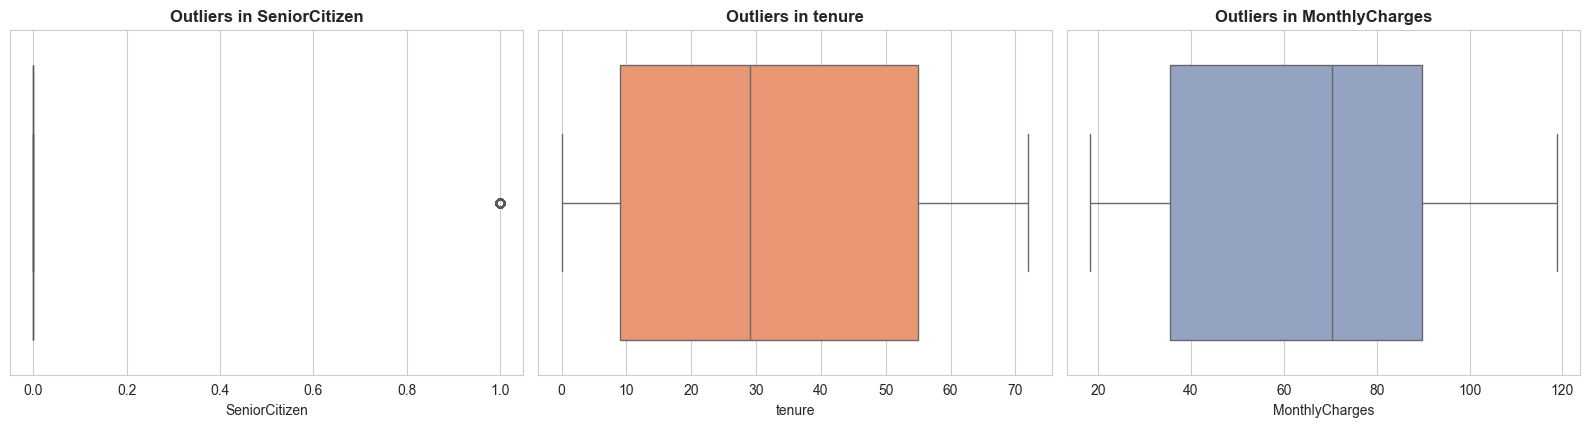

In [59]:
#Boxplots for Outliers
colors = sns.color_palette("Set2", len(num_cols))
plt.figure(figsize=(16,12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df[col],color=colors[i-1])
    plt.title(f'Outliers in {col}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

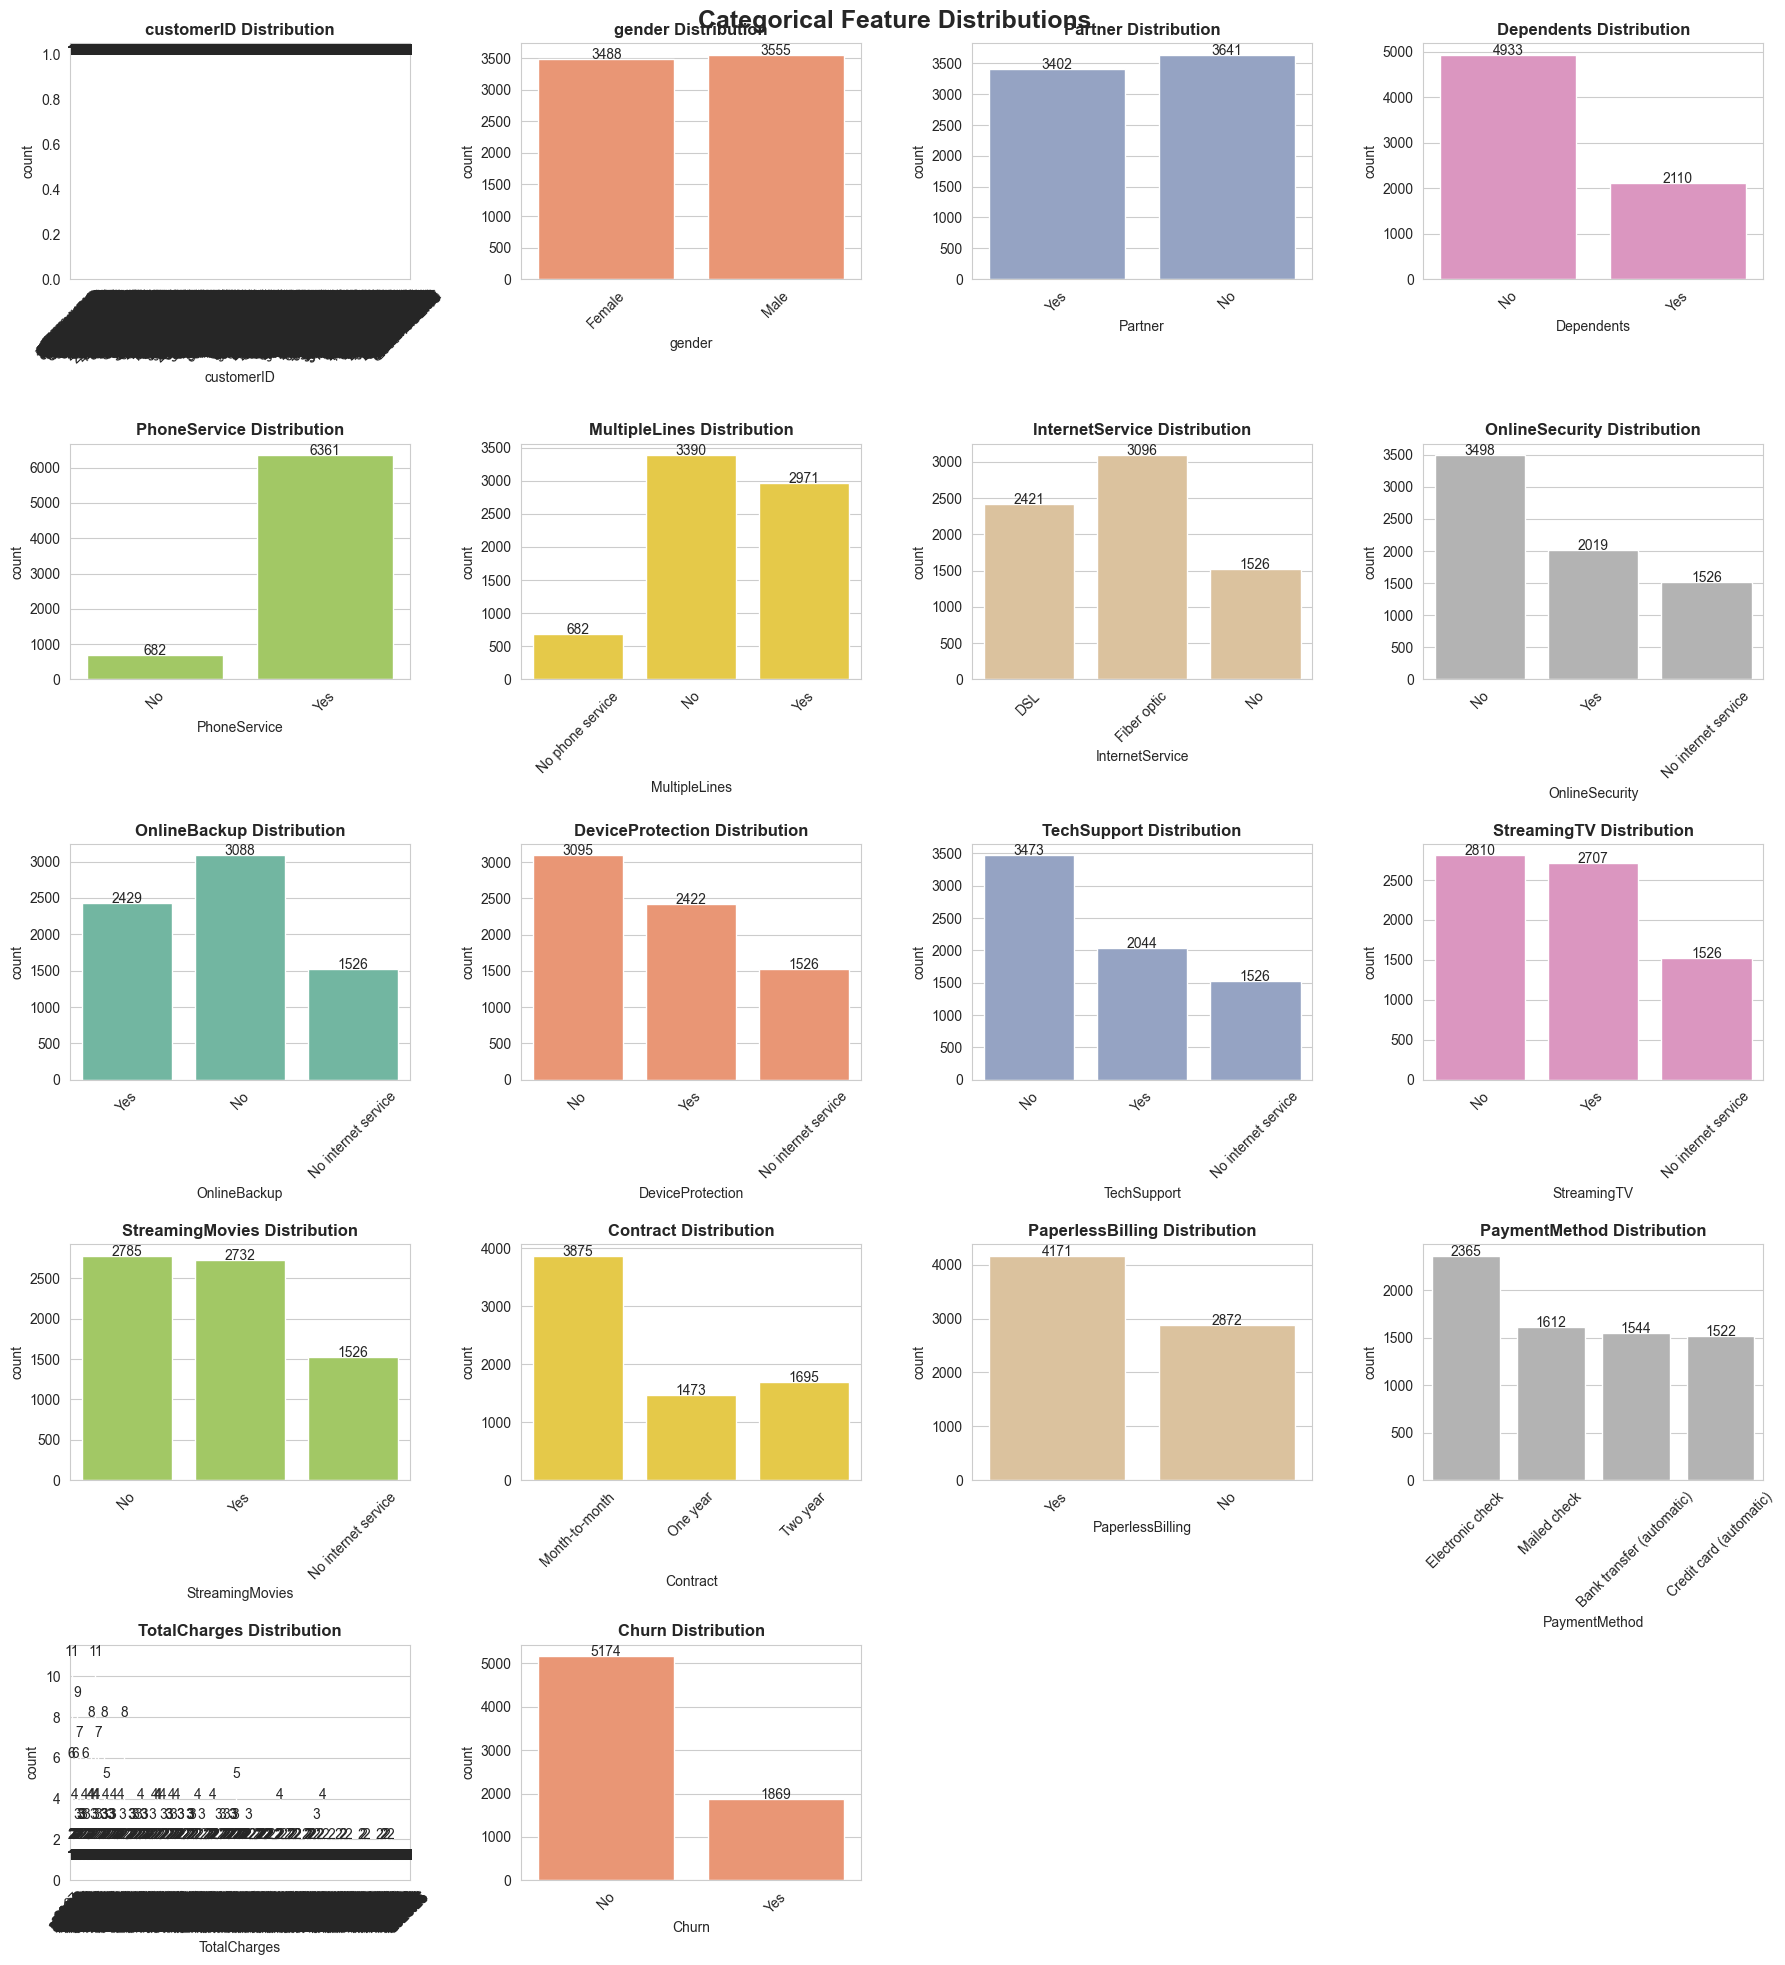

In [63]:
#Categorical Feature Analysis
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols
#exampal
# Categorical Feature Distribution
import math
n_cols = 4
n_rows = math.ceil(len(cat_cols) / n_cols)
plt.figure(figsize=(18, n_rows*4))
colors = sns.color_palette("Set2", len(cat_cols))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    ax = sns.countplot(x=col,data=df,color=colors[i-1])
    plt.xticks(rotation=45)
    plt.title(f'{col} Distribution', fontsize=12, fontweight='bold')
    
    # value labels
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2,height,int(height),ha="center")

plt.suptitle("Categorical Feature Distributions",fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

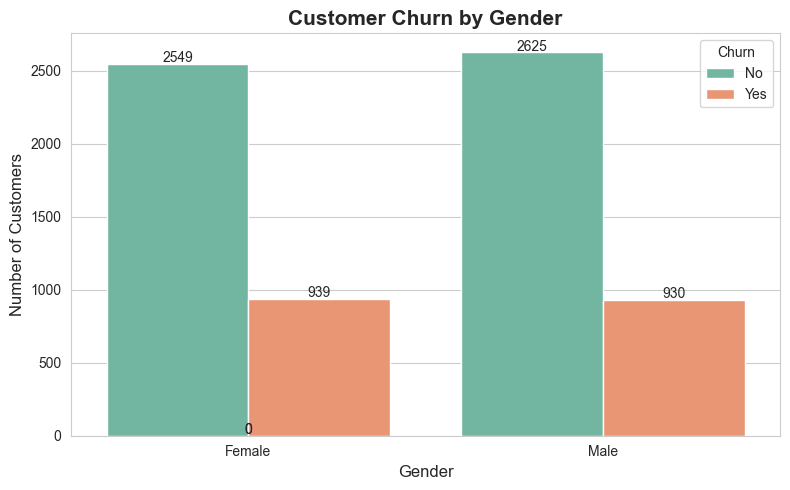

In [64]:
#Churn vs Gender
plt.figure(figsize=(8,5))
ax = sns.countplot(x='gender',hue='Churn',data=df,palette='Set2')
plt.title("Customer Churn by Gender", fontsize=15, fontweight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Add value labels
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,height + 10,int(height),ha="center",fontsize=10)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

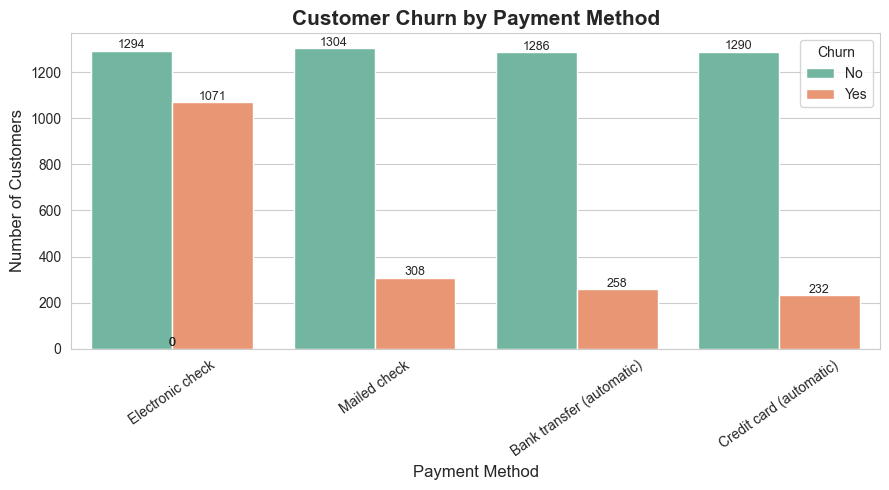

In [65]:
#Churn vs Payment Method
plt.figure(figsize=(9,5))
ax = sns.countplot(x='PaymentMethod',hue='Churn',data=df,palette='Set2')
plt.title("Customer Churn by Payment Method", fontsize=15, fontweight='bold')
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks(rotation=35)

# Add count labels
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,height + 10,int(height),ha="center",fontsize=9)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

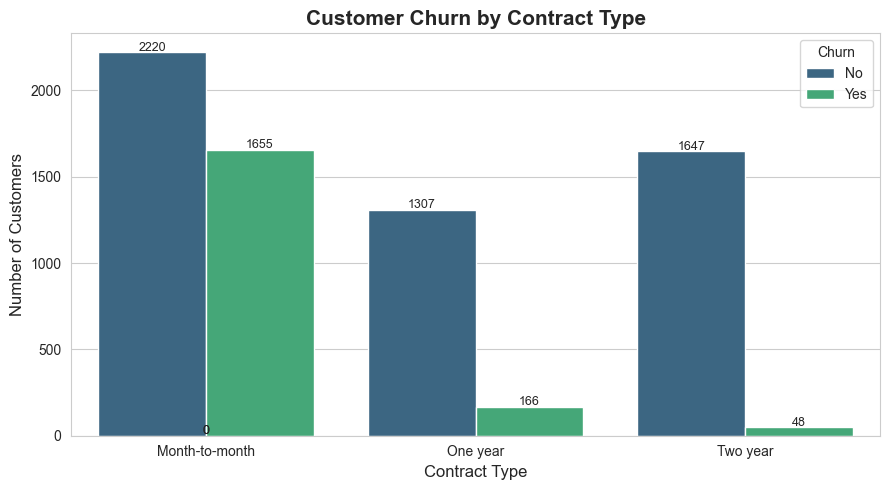

In [68]:
#Contract vs Churn
plt.figure(figsize=(9,5))
ax = sns.countplot(x='Contract',hue='Churn',data=df,palette='viridis')
plt.title("Customer Churn by Contract Type", fontsize=15, fontweight='bold')
plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Add value labels
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,height + 10,int(height),ha="center",fontsize=9)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

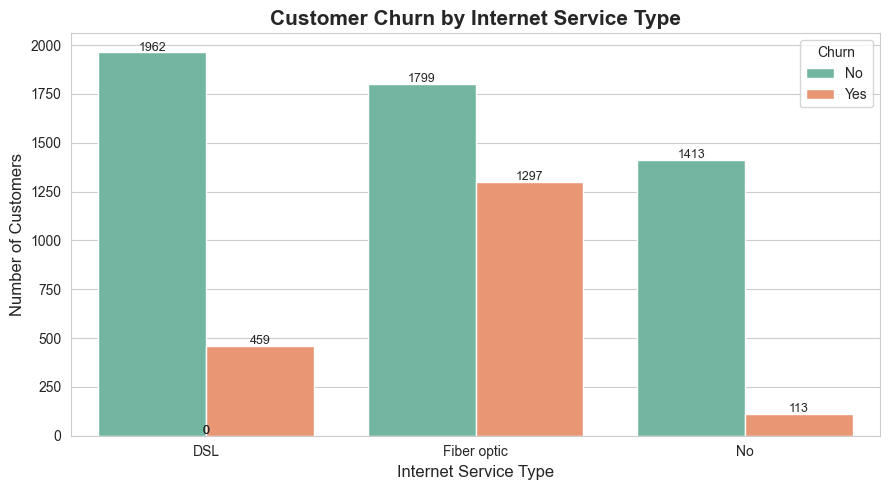

In [69]:
#Internet Service vs Churn
plt.figure(figsize=(9,5))
ax = sns.countplot(x='InternetService',hue='Churn',data=df,palette='Set2')
plt.title("Customer Churn by Internet Service Type", fontsize=15, fontweight='bold')
plt.xlabel("Internet Service Type", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# add count labels
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2,height + 10,int(height),ha="center",fontsize=9)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

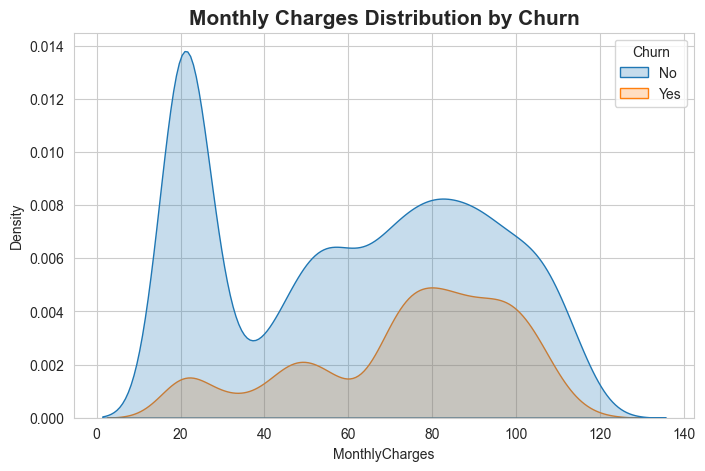

In [73]:
#Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.kdeplot(data=df,x='MonthlyCharges',hue='Churn',fill=True)
plt.title("Monthly Charges Distribution by Churn", fontsize=15, fontweight='bold')
plt.show()

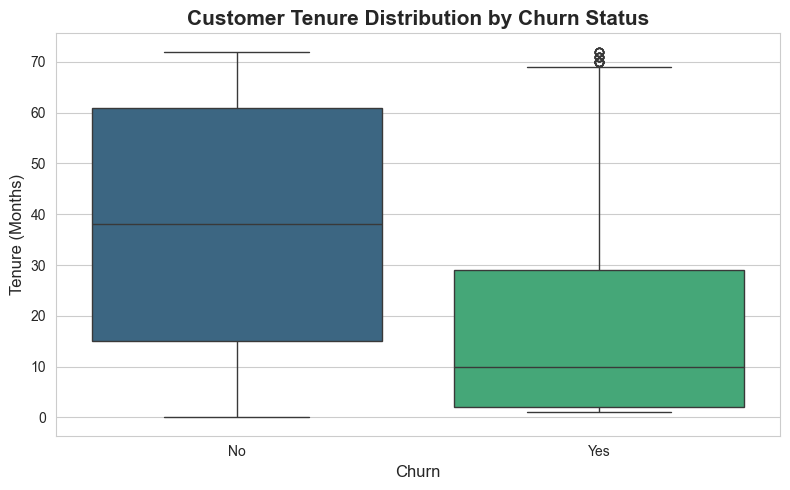

In [74]:
#Tenure vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='tenure',data=df,palette='viridis')
plt.title("Customer Tenure Distribution by Churn Status", fontsize=15, fontweight='bold')
plt.xlabel("Churn", fontsize=12)
plt.ylabel("Tenure (Months)", fontsize=12)
plt.tight_layout()
plt.show()

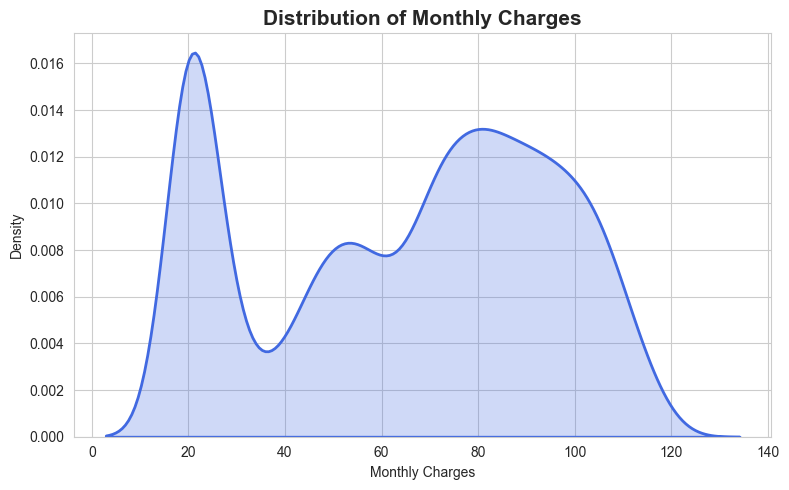

In [75]:
#KDE Distribution
plt.figure(figsize=(8,5))
sns.kdeplot(data=df,x='MonthlyCharges',fill=True,color='royalblue',linewidth=2)
plt.title("Distribution of Monthly Charges", fontsize=15, fontweight='bold')
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

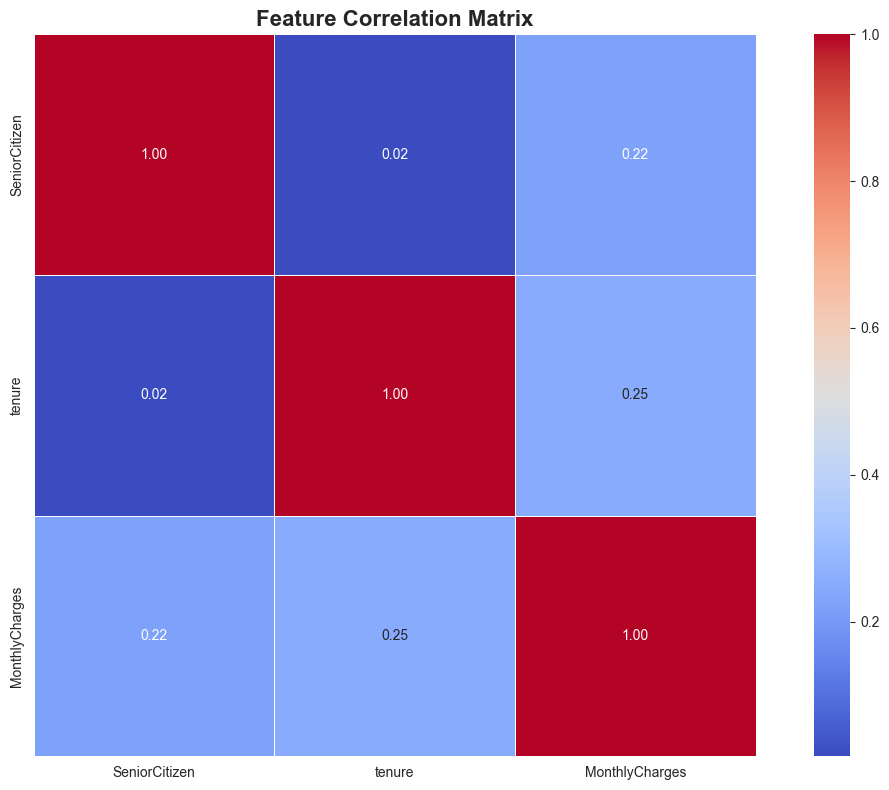

In [76]:
#Correlation Matrix
# Select numerical columns
numeric_df = df.select_dtypes(include=['int64','float64'])
corr = numeric_df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,square=True)
plt.title("Feature Correlation Matrix", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

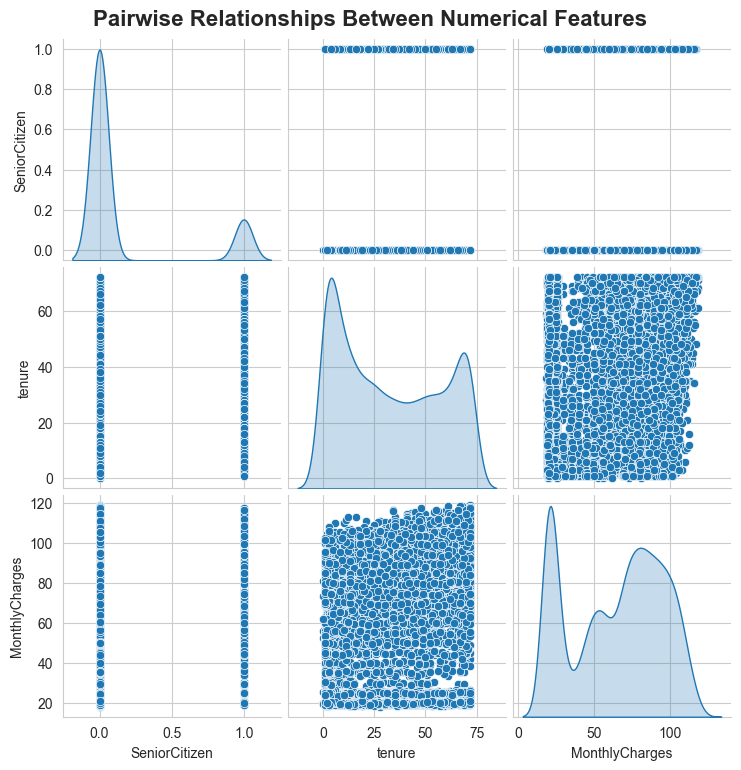

In [77]:
#Pairplot (Feature Relationships)
sns.pairplot(df[num_cols],diag_kind="kde")
plt.suptitle("Pairwise Relationships Between Numerical Features",y=1.02,fontsize=16,fontweight="bold")
plt.show()

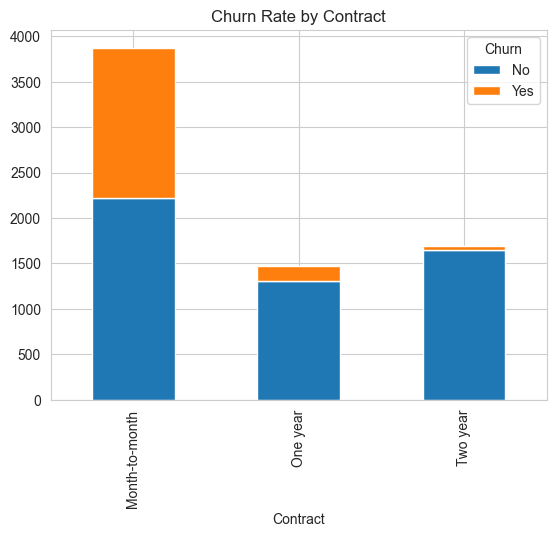

In [29]:
#Churn Rate by Contract
contract_churn = pd.crosstab(df['Contract'], df['Churn'])
contract_churn.plot(kind="bar", stacked=True)
plt.title("Churn Rate by Contract")
plt.show()

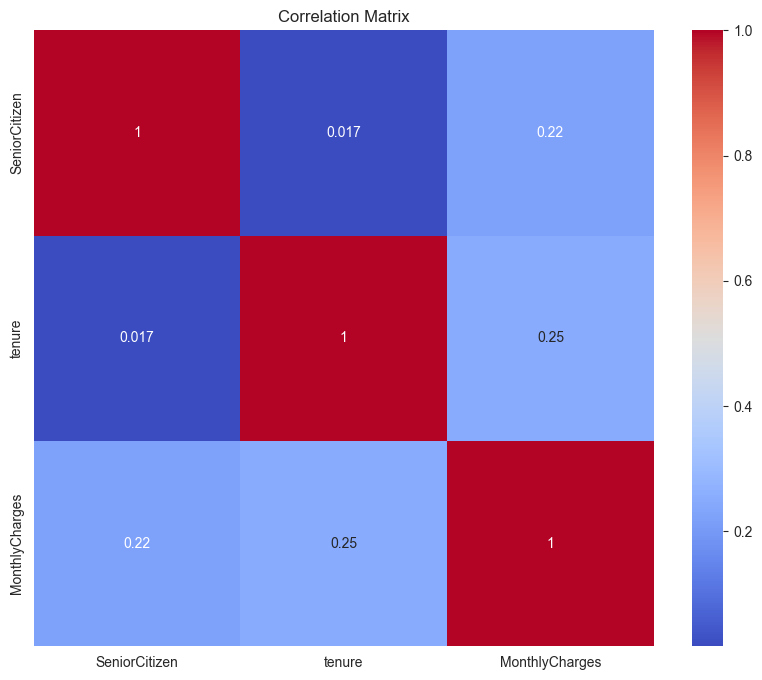

In [35]:
#Correlation Analysis
corr = numeric_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

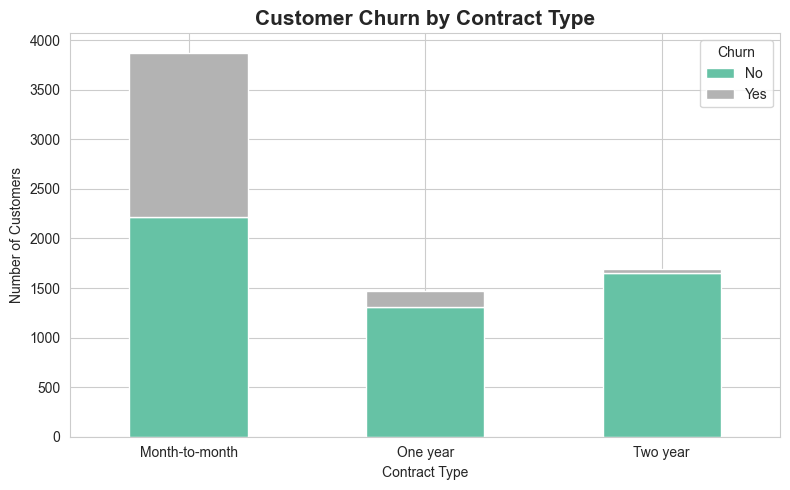

In [78]:
#Churn Rate by Internet Service
contract_churn = pd.crosstab(df['Contract'], df['Churn'])
contract_churn.plot(kind="bar",stacked=True,colormap="Set2",figsize=(8,5))
plt.title("Customer Churn by Contract Type", fontsize=15, fontweight="bold")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

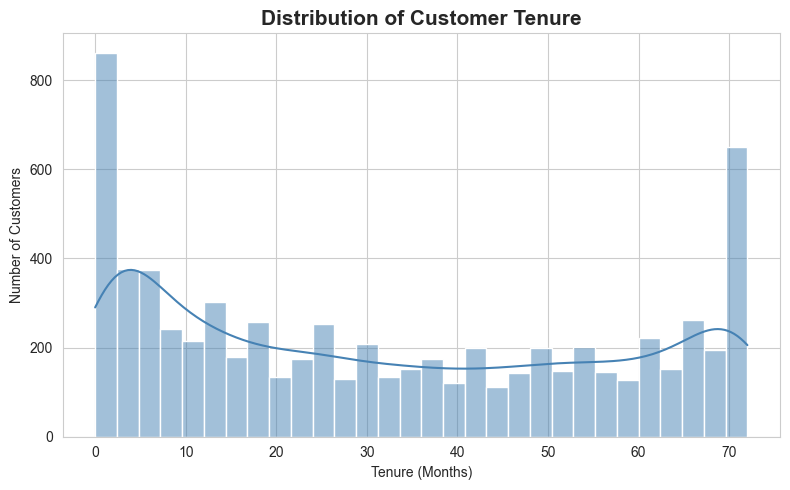

In [79]:
#Customer Tenure Distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='tenure',bins=30,kde=True,color='steelblue')
plt.title("Distribution of Customer Tenure", fontsize=15, fontweight="bold")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()